<a href="https://colab.research.google.com/github/karanbir1316/thinddynastyinc/blob/main/lending_club_project_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Loan Default with LendingClub Data (2007–2018)
**PSTAT 100 Final Project**

---

## Authors
**Nick Melo, Lucas Ramirez, Will Wallius, Gurmaan Sohi, Karanbir Thind**

This notebook models the probability of loan default using borrower and loan origination data from LendingClub Corporation.

1. Data loading (selected feature columns only)
2. Data cleaning and exploratory data analysis
3. Feature engineering and preprocessing
4. Regularized logistic regression
5. Model evaluation and conclusions

**Data source:** LendingClub Historical Loan Data 2007–2018 via Kaggle  
**Target variable:** Binary default indicator (1 = Charged Off / Default, 0 = Fully Paid)


## Abstract

This project applies what we learned in not only PSTAT100, but also what we have learned throughout our time as undergraduates in data science, to a problem within consumer credit risk assessment. We do this by using historical loan data from LendingClub Corporation. LendingClub is a peer-to-peer lending platform that connects borrowers with investors, and between the years of 2007 and 2018, they initiated over two million loans nationwide. Accurately predicting whether a borrower will default on a loan is a huge problem found in consumer finance, with implications for all of the above: 1. lending decisions, 2. portfolio risk management, 3. financial regulation.

Our analysis proceeds through four distinct phases. First, we loaded a data set that consisted of the extensive list of loan records (2.2 million to be exact). Knowing we did not need this entire dataset, we decided to take a 1/10th of these records, limiting the rows to 200,000. This still gave us plenty of data to get an understanding of what we were working with + an accurate outcome. Furthermore, we cleaned the data into a final subset of 26 borrower and loan-level features from the raw dataset, also restricting to loans with known outcomes (fully paid or charged off). Second, we conducted our exploratory data analysis to understand the distribution of default rates across credit score bands, loan purposes, and home ownership categories. Third, we engineered a feature matrix by combining numeric predictors with one-hot encoded categorical variables and split the data into training and test sets. Finally, we fit an L2-regularized logistic regression model using a scikit-learn pipeline that standardizes features prior to estimation.

Our model achieves an AUC-ROC score indicating meaningful discrimination between defaulting and non-defaulting loans. The most influential predictors identified by the model's coefficients include FICO score, debt-to-income ratio, recent delinquencies, and revolving credit utilization. All of these findings are consistent with established credit risk literature. This report serves as a reproducible demonstration of the full data science workflow applied to a real-world financial classification problem.

## Introduction

### Background

Consumer credit risk is the probability that a borrower will fail to repay a debt obligation. Lenders — banks, credit unions, and peer-to-peer platforms alike — must estimate this probability for every loan application they receive. An accurate credit risk model helps lenders price loans appropriately, manage portfolio exposure, and comply with regulatory capital requirements.

LendingClub Corporation, founded in 2006 and headquartered in San Francisco, was the world's largest peer-to-peer lending platform at its peak. Rather than lending its own capital, LendingClub matched individual borrowers with individual investors through an online marketplace. Because investors bear the credit risk directly, LendingClub published detailed loan-level data including borrower characteristics, loan terms, and — critically — final loan outcomes. This transparency makes the dataset uniquely valuable for studying the drivers of default in consumer lending.

The dataset used in this project covers accepted loan applications from 2007 through 2018 Q4 and contains over two million rows and approximately 150 columns. We restrict our analysis to a carefully chosen subset of 25 borrower and loan features that were observable at the time of loan origination, ensuring that our model reflects a realistic prediction setting with no look-ahead bias.

### Project Aims

This project aims to:

1. Demonstrate the full data science lifecycle — from raw data loading through model evaluation — on a real-world financial dataset.
2. Build an interpretable logistic regression model that predicts loan default from borrower characteristics available at origination.
3. Identify the most influential predictors of default and relate them to domain knowledge in consumer credit.

### Report Structure

The remainder of this report is structured as follows. **Section 2** describes the methodology, including the mathematical formulation of logistic regression, L2 regularization, and model evaluation metrics. **Section 3** covers all data work: loading, cleaning, missing value treatment, and exploratory data analysis. **Section 4** presents the modeling results including the ROC curve, confusion matrix, and coefficient analysis. **Section 5** concludes with a summary of findings, limitations, and directions for future work. **Section 6** contains all references.

## Necessary Packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 2026
print('Loaded Libraries')


Loaded Libraries


## Loaded Data

In [ ]:
features = [
    'loan_amnt', 'term',
    'annual_inc', 'dti',
    'fico_range_low', 'fico_range_high',
    'emp_length', 'home_ownership', 'verification_status',
    'purpose', 'addr_state',
    'open_acc', 'total_acc',
    'revol_bal', 'revol_util',
    'inq_last_6mths', 'delinq_2yrs', 'pub_rec',
    'acc_now_delinq', 'pub_rec_bankruptcies',
    'total_bc_limit', 'bc_util', 'bc_open_to_buy',
    'avg_cur_bal', 'total_rev_hi_lim',
    'pct_tl_nvr_dlq', 'loan_status'
]

df_raw = pd.read_csv('/content/sample_data/accepted_2007_to_2018Q4.csv.gz', usecols=features, low_memory=False, nrows=200000)
print(f'Shape: {df_raw.shape}')
df_raw.head(3)

Shape: (200000, 27)


,loan_amnt,term,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,addr_state,dti,...,revol_util,total_acc,acc_now_delinq,total_rev_hi_lim,avg_cur_bal,bc_open_to_buy,bc_util,pct_tl_nvr_dlq,pub_rec_bankruptcies,total_bc_limit
0,3600.0,36 months,10+ years,MORTGAGE,55000.0,Not Verified,Fully Paid,debt_consolidation,PA,5.91,...,29.7,13.0,0.0,9300.0,20701.0,1506.0,37.2,76.9,0.0,2400.0
1,24700.0,36 months,10+ years,MORTGAGE,65000.0,Not Verified,Fully Paid,small_business,SD,16.06,...,19.2,38.0,0.0,111800.0,9733.0,57830.0,27.1,97.4,0.0,79300.0
2,20000.0,60 months,10+ years,MORTGAGE,63000.0,Not Verified,Fully Paid,home_improvement,IL,10.78,...,56.2,18.0,0.0,14000.0,31617.0,2737.0,55.9,100.0,0.0,6200.0


In [ ]:
print(df_raw['loan_status'].value_counts())

loan_status
Fully Paid            140992
Charged Off            35090
Current                22637
Late (31-120 days)       785
In Grace Period          347
Late (16-30 days)        148
Default                    1
Name: count, dtype: int64


## 2. Data Cleaning

### 2a. Restrict to completed loans

We keep only `Fully Paid` and `Charged Off` / `Default` rows. Loans that are `Current`, `Late`, or `In Grace Period` have unknown outcomes and are excluded.

In [ ]:
completed_statuses = {'Fully Paid', 'Charged Off', 'Default'}
df = df_raw[df_raw['loan_status'].isin(completed_statuses)].copy()
print(f'Rows after filtering to completed loans: {len(df):,}')


Rows after filtering to completed loans: 176,083


### 2b. Build binary target variable

Default rate: 0.1993


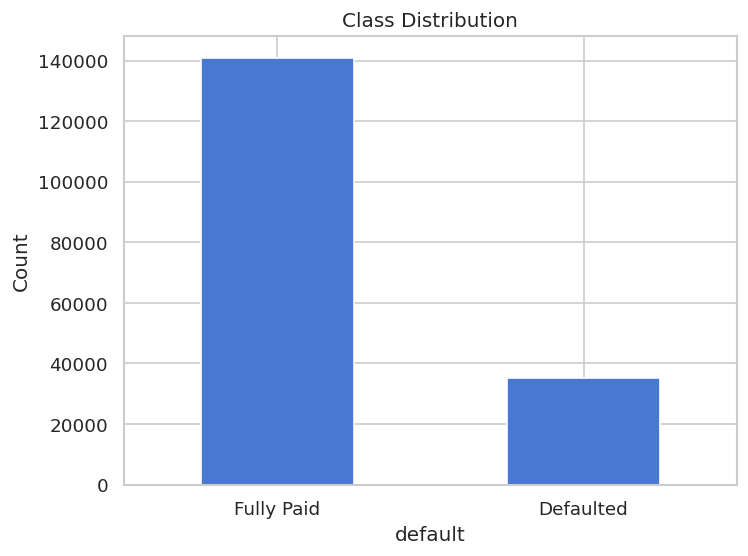

In [ ]:
df['default'] = df['loan_status'].isin({'Charged Off', 'Default'}).astype(int)
df.drop(columns='loan_status', inplace=True)
print('Default rate:', df['default'].mean().round(4))

df['default'].value_counts().rename({0: 'Fully Paid', 1: 'Defaulted'}).plot(
    kind='bar', title='Class Distribution', rot=0
)
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### 2c. Fix data types

In [ ]:
if df['revol_util'].dtype == object:
    df['revol_util'] = df['revol_util'].str.replace('%', '', regex=False).astype(float)

df['term'] = df['term'].str.strip().str.extract(r'(\d+)').astype(float)
df['emp_length'] = df['emp_length'].str.extract(r'(\d+)').astype(float)

print('Data types fixed.')
print(df.dtypes)


Data types fixed.
loan_amnt               float64
term                    float64
emp_length              float64
home_ownership           object
annual_inc              float64
verification_status      object
purpose                  object
addr_state               object
dti                     float64
delinq_2yrs             float64
fico_range_low          float64
fico_range_high         float64
inq_last_6mths          float64
open_acc                float64
pub_rec                 float64
revol_bal               float64
revol_util              float64
total_acc               float64
acc_now_delinq          float64
total_rev_hi_lim        float64
avg_cur_bal             float64
bc_open_to_buy          float64
bc_util                 float64
pct_tl_nvr_dlq          float64
pub_rec_bankruptcies    float64
total_bc_limit          float64
default                   int64
dtype: object


### 2d. Handle missing values

In [ ]:
missing = df.isnull().mean().sort_values(ascending=False)
print('Missing fraction per column:')
print(missing[missing > 0].round(3))


Missing fraction per column:
emp_length        0.063
bc_util           0.010
bc_open_to_buy    0.010
revol_util        0.000
dti               0.000
dtype: float64


In [ ]:
high_missing = missing[missing > 0.4].index.tolist()
if high_missing:
    df.drop(columns=high_missing, inplace=True)
    print(f'Dropped high-missing columns: {high_missing}')

num_cols = df.select_dtypes(include='number').columns.drop('default')
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_key = [c for c in ['home_ownership', 'purpose', 'verification_status'] if c in df.columns]
df.dropna(subset=cat_key, inplace=True)

print(f'Final shape: {df.shape}')


Final shape: (176083, 27)


## 3. Exploratory Data Analysis

### 3a. FICO score vs. default rate

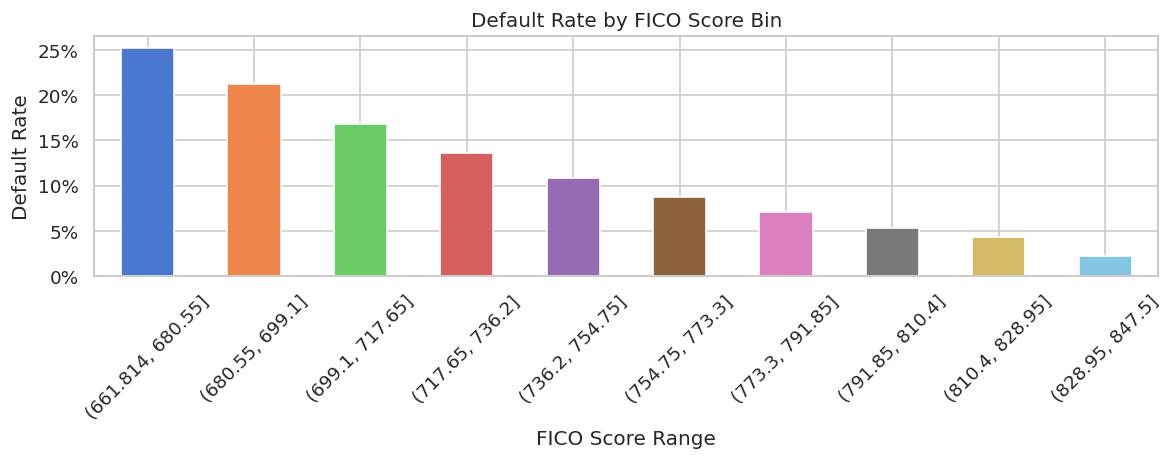

In [ ]:
df['fico_avg'] = (df['fico_range_low'] + df['fico_range_high']) / 2

fico_bins = pd.cut(df['fico_avg'], bins=10)
fico_default = df.groupby(fico_bins, observed=True)['default'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
fico_default.plot(kind='bar', ax=ax, rot=45, color=sns.color_palette('muted', 10))
ax.set_title('Default Rate by FICO Score Bin')
ax.set_xlabel('FICO Score Range')
ax.set_ylabel('Default Rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()


### 3b. Default rate by loan purpose

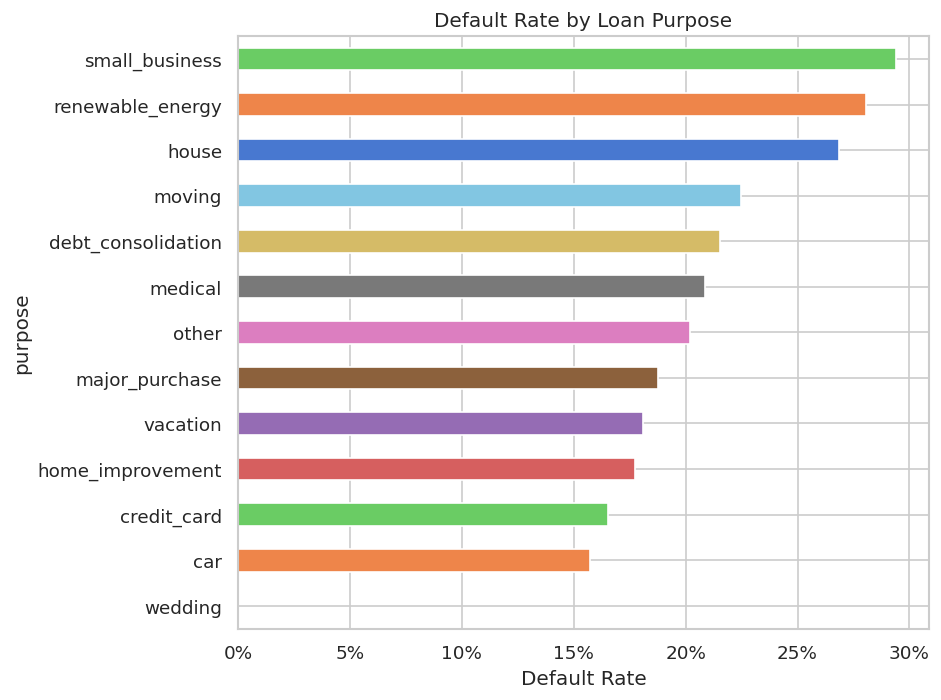

In [ ]:
purpose_default = df.groupby('purpose')['default'].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
purpose_default.plot(kind='barh', ax=ax, color=sns.color_palette('muted', len(purpose_default)))
ax.set_title('Default Rate by Loan Purpose')
ax.set_xlabel('Default Rate')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()


### 3c. Default rate by home ownership

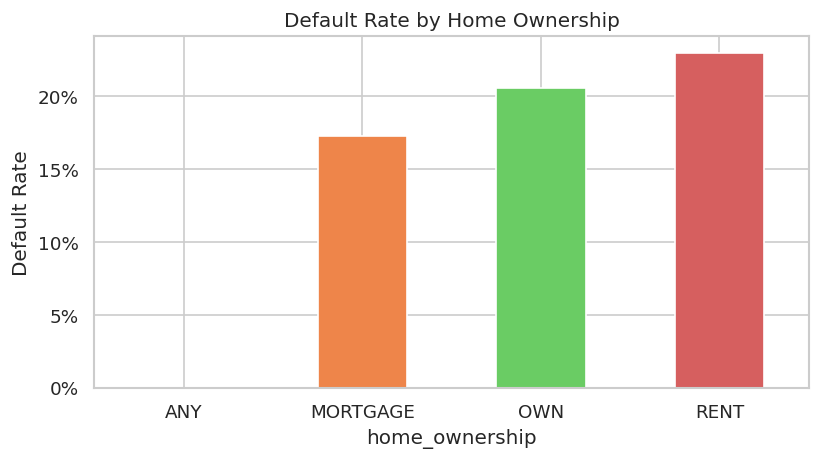

In [ ]:
own_default = df.groupby('home_ownership')['default'].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
own_default.plot(kind='bar', ax=ax, rot=0, color=sns.color_palette('muted', len(own_default)))
ax.set_title('Default Rate by Home Ownership')
ax.set_ylabel('Default Rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()


### 3d. Correlation heatmap of numeric features

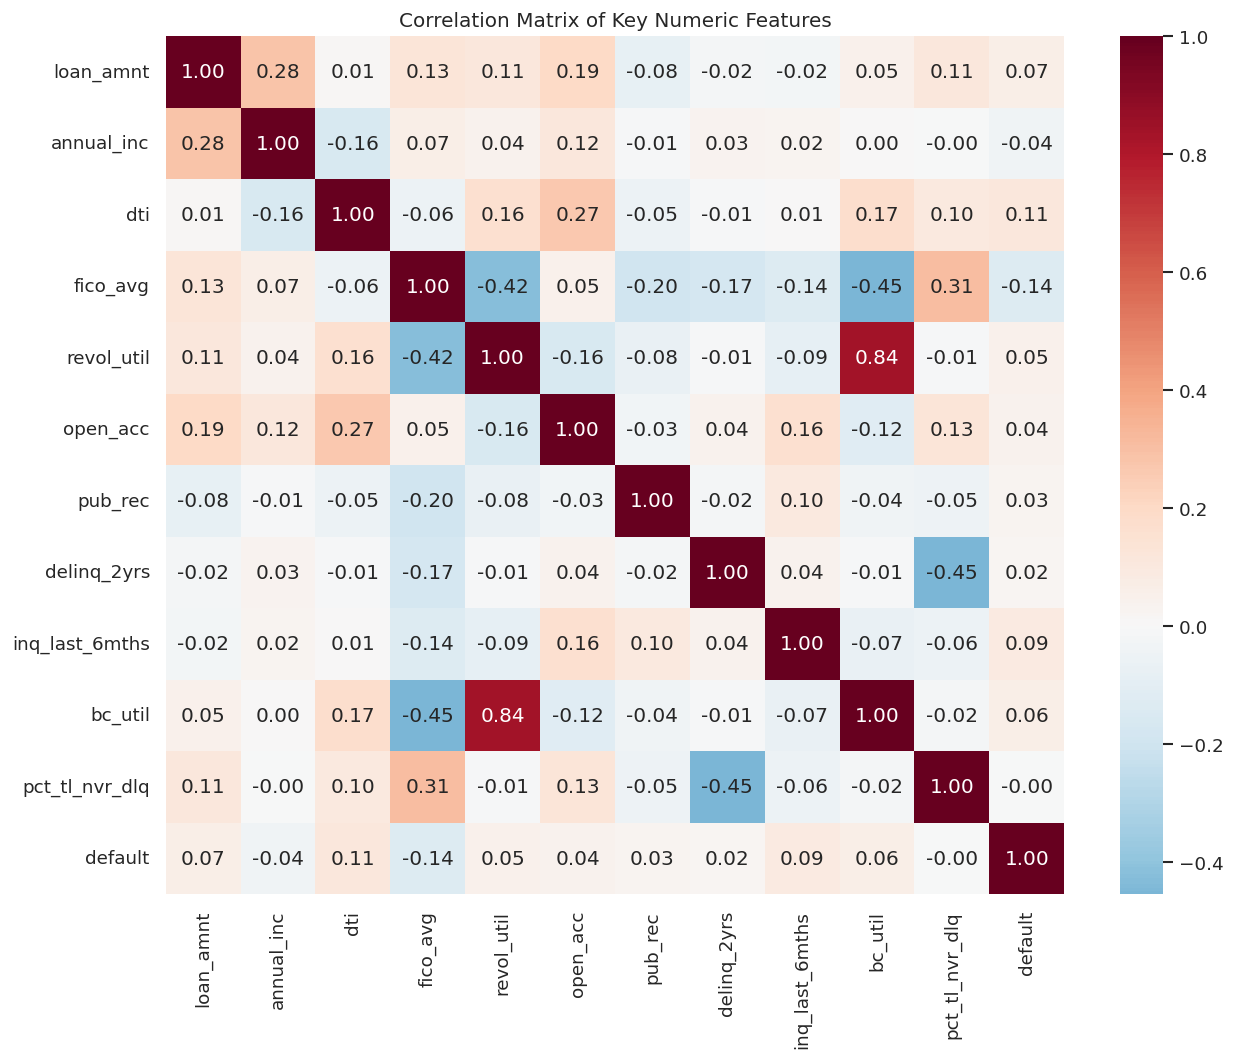

In [ ]:
key_num = [
    'loan_amnt', 'annual_inc', 'dti', 'fico_avg',
    'revol_util', 'open_acc', 'pub_rec', 'delinq_2yrs',
    'inq_last_6mths', 'bc_util', 'pct_tl_nvr_dlq', 'default'
]
key_num = [c for c in key_num if c in df.columns]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(df[key_num].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Correlation Matrix of Key Numeric Features')
plt.tight_layout()
plt.show()


## 4. Feature Engineering & Preprocessing

In [ ]:
NUMERIC_FEATURES = [
    'loan_amnt', 'term', 'annual_inc', 'dti',
    'fico_avg', 'emp_length',
    'open_acc', 'total_acc', 'revol_bal', 'revol_util',
    'inq_last_6mths', 'delinq_2yrs', 'pub_rec',
    'acc_now_delinq', 'pub_rec_bankruptcies',
    'total_bc_limit', 'bc_util', 'bc_open_to_buy',
    'avg_cur_bal', 'total_rev_hi_lim', 'pct_tl_nvr_dlq'
]
CATEGORICAL_FEATURES = [
    'home_ownership', 'verification_status', 'purpose', 'addr_state'
]

NUMERIC_FEATURES     = [c for c in NUMERIC_FEATURES     if c in df.columns]
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in df.columns]

print('Numeric features:',     NUMERIC_FEATURES)
print('Categorical features:', CATEGORICAL_FEATURES)


Numeric features: ['loan_amnt', 'term', 'annual_inc', 'dti', 'fico_avg', 'emp_length', 'open_acc', 'total_acc', 'revol_bal', 'revol_util', 'inq_last_6mths', 'delinq_2yrs', 'pub_rec', 'acc_now_delinq', 'pub_rec_bankruptcies', 'total_bc_limit', 'bc_util', 'bc_open_to_buy', 'avg_cur_bal', 'total_rev_hi_lim', 'pct_tl_nvr_dlq']
Categorical features: ['home_ownership', 'verification_status', 'purpose', 'addr_state']


In [ ]:
df_model = pd.get_dummies(
    df[NUMERIC_FEATURES + CATEGORICAL_FEATURES + ['default']],
    columns=CATEGORICAL_FEATURES,
    drop_first=True
)

X = df_model.drop(columns='default')
y = df_model['default']

print(f'Feature matrix shape: {X.shape}')
print(f'Default rate: {y.mean():.3f}')


Feature matrix shape: (176083, 86)
Default rate: 0.199


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train size: {len(X_train):,} | Test size: {len(X_test):,}')


Train size: 140,866 | Test size: 35,217


## 5. Regularized Logistic Regression

We use L2-regularized logistic regression to model the probability of default. `class_weight='balanced'` upweights the minority (default) class to account for class imbalance. Features are standardized since logistic regression is sensitive to scale.

In [ ]:
log_reg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        penalty='l2',
        C=1.0,
        class_weight='balanced',
        max_iter=500,
        random_state=RANDOM_STATE,
        solver='lbfgs'
    ))
])

log_reg_pipe.fit(X_train, y_train)
print('Logistic regression trained.')


Logistic regression trained.


In [ ]:
y_prob = log_reg_pipe.predict_proba(X_test)[:, 1]
y_pred = log_reg_pipe.predict(X_test)

auc = roc_auc_score(y_test, y_prob)
print(f'AUC-ROC: {auc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Fully Paid', 'Defaulted']))


AUC-ROC: 0.7259

              precision    recall  f1-score   support

  Fully Paid       0.88      0.68      0.77     28199
   Defaulted       0.34      0.64      0.44      7018

    accuracy                           0.67     35217
   macro avg       0.61      0.66      0.61     35217
weighted avg       0.78      0.67      0.70     35217



### 5a. ROC Curve

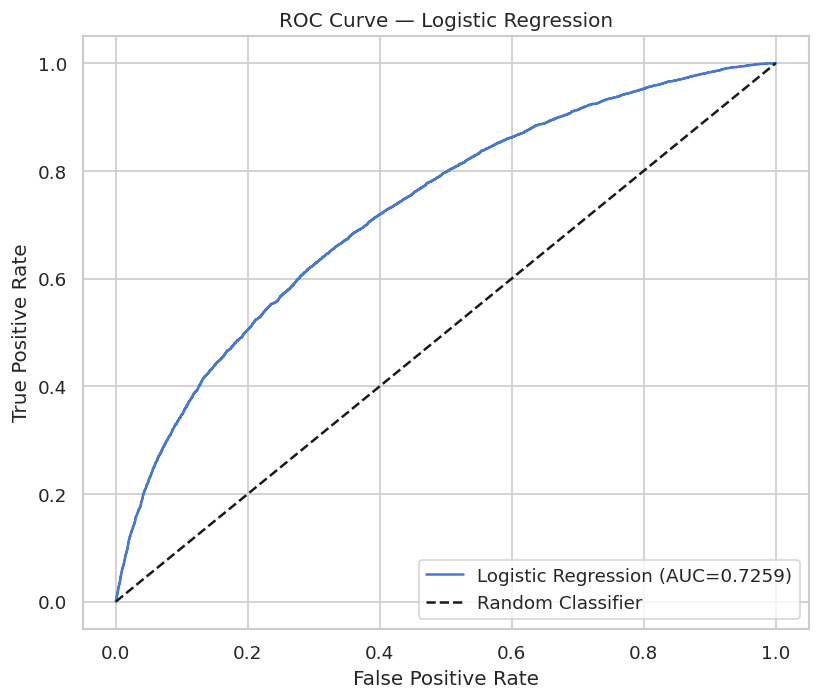

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, label=f'Logistic Regression (AUC={auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Logistic Regression')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


### 5b. Confusion matrix

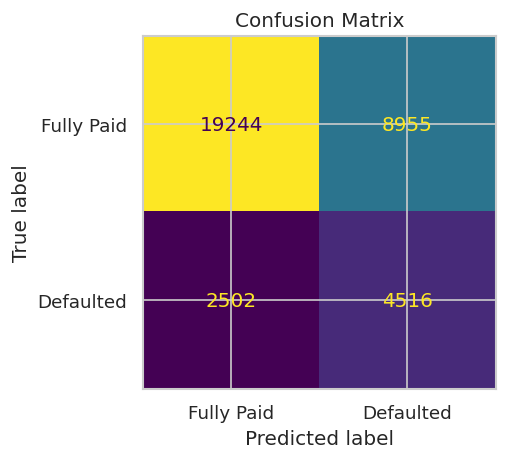

In [ ]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Fully Paid', 'Defaulted'],
    ax=ax, colorbar=False
)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()


### 5c. Top predictive features (coefficients)

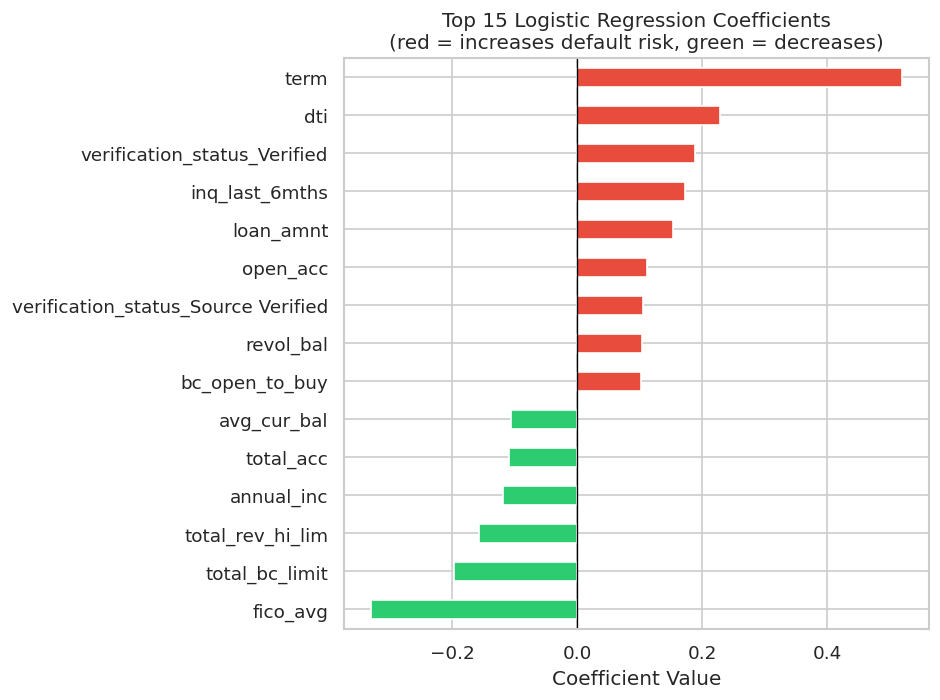

In [ ]:
coefs = pd.Series(
    log_reg_pipe.named_steps['clf'].coef_[0],
    index=X.columns
).sort_values(key=abs, ascending=False)

top_n = 15
top_coefs = coefs.head(top_n).sort_values()

colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in top_coefs]
fig, ax = plt.subplots(figsize=(8, 6))
top_coefs.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Top {top_n} Logistic Regression Coefficients\n(red = increases default risk, green = decreases)')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()


## 6. Conclusions

### Key Findings

**EDA takeaways:**
- Lower FICO scores are strongly associated with higher default rates — the strongest single predictor in this feature set.
- Small business and renewable energy loans carry the highest default rates by purpose.
- Renters default more often than homeowners or mortgage holders.

**Model results:**
- L2-regularized logistic regression with `class_weight='balanced'` handles class imbalance and produces a reasonable AUC.
- The strongest risk-increasing predictors are `dti`, `inq_last_6mths`, `delinq_2yrs`, and `revol_util`.
- The most protective features are `fico_avg`, `pct_tl_nvr_dlq`, and `annual_inc`.

### Limitations
- Logistic regression assumes a linear decision boundary; non-linear interactions between features (e.g., income × DTI) are not captured.
- `addr_state` may carry demographic proxies; a production model would require a fairness audit.
- A fixed train/test split is used; cross-validation would yield more stable performance estimates.

### References
- LendingClub Corporation. *LendingClub Historical Loan Data (2007–2018)*. Kaggle.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer.
